In [ ]:
!hostname 

gpua087.delta.ncsa.illinois.edu


In [2]:
import scanpy as sc
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
ad.settings.allow_write_nullable_strings = True
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import decoupler

/projects/bgdb/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/projects/bgdb/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/projects/bgdb/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [3]:
import os
os.chdir('/projects/bgdb/asachan/bioinfo_analysis/human_SKM_multimodal_analysis/py_scripts')  # directory containing utils.py
import sys
import logging
import warnings

export_dir = "/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human"
raw_dir = "/work/hdd/bgdb/asachan/datasets_hdd/SKM_ageing_human/raw_files"

In [4]:
from utils import *

In [48]:
adata_rna = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/rna_objects/rna_female_type2_ds_wrt_HALLMARK_DNA_REPAIR.h5ad'
out_tmp = '/projects/bgdb/asachan/tmp'

In [49]:
rna_adata = sc.read_h5ad(adata_rna)

In [50]:
rna_adata.obs['sample'].value_counts()

sample
YM2    1989
OM9    1278
OM6     722
P26     122
Name: count, dtype: int64

### Downsampling to retain only certain humans of interest

In [ ]:
# filter out OM2 cells
rna_adata = rna_adata[rna_adata.obs['sample'] != 'OM2'].copy()
# filter out YM2_1 cells
rna_adata = rna_adata[rna_adata.obs['orig.ident'] != 'YM2_1'].copy()
rna_adata.obs['orig.ident'].value_counts()

orig.ident
OM9_N1    2324
OM9_N2    2290
OM9_D4    2264
OM9_D1    2125
OM9_D2    1669
OM9_D3    1620
OM9_N4    1526
OM9_N3    1499
YM2_2     1139
OM6_3      978
OM6_4      937
YM2_3      850
OM6_2      830
OM6_1      691
P26_2       45
P26_5       40
P26_4       26
P26_1       11
Name: count, dtype: int64

#### Downsampling OM9 to remove gluteus medius (GM) cells

In [8]:
OM9_adata = rna_adata[rna_adata.obs['sample'] == 'OM9'].copy()

In [9]:
import pandas as pd

adata = OM9_adata
# Subset by orig.ident, extract the trailing suffix from each cell ID,
# and check whether every cell in a given orig.ident shares the same suffix.

SAMPLE_COL = "orig.ident"

# Pull the trailing suffix from CELL<num>_<N|D><1-4>_<suffix>
suffix = adata.obs.index.to_series().str.extract(r'_[ND][1-4]_(.+)$')[0]
adata.obs['_suffix'] = suffix.values

# Per orig.ident: which suffix(es) appear, and how often
report = (
    adata.obs.groupby(SAMPLE_COL)['_suffix']
    .value_counts()
    .unstack(fill_value=0)
)

# Quick verdict per orig.ident
verdict = []
for samp, row in report.iterrows():
    nonzero = row[row > 0]
    if len(nonzero) == 1:
        verdict.append((samp, 'clean', nonzero.index[0], int(nonzero.iloc[0]), 1.0))
    else:
        top = nonzero.idxmax()
        purity = nonzero.max() / nonzero.sum()
        verdict.append((samp, 'mixed', top, int(nonzero.max()), round(purity, 3)))

verdict_df = pd.DataFrame(verdict, columns=[SAMPLE_COL, 'status', 'dominant_suffix',
                                            'dominant_count', 'purity'])
print("Per-orig.ident verdict:")
print(verdict_df.to_string(index=False))

adata.obs.drop(columns='_suffix', inplace=True)

Per-orig.ident verdict:
orig.ident status dominant_suffix  dominant_count  purity
    OM9_D1  clean         1_1_7_1            2112     1.0
    OM9_D2  clean         2_1_7_1            1669     1.0
    OM9_D3  clean           1_7_1            1620     1.0
    OM9_D4  clean           2_7_1            2264     1.0
    OM9_N1  clean         1_1_8_1            2324     1.0
    OM9_N2  clean         2_1_8_1            2290     1.0
    OM9_N3  clean           1_8_1            1498     1.0
    OM9_N4  clean           2_8_1            1526     1.0


In [10]:
import pandas as pd
from pathlib import Path
import re

# ============ CONFIG ============
RAW_BC_DIR = Path("/work/hdd/bgdb/asachan/datasets_hdd/SKM_multimodal_ageing/raw_files/female_type2_maxtoki/OM9")
FNAME_TMPL = "OM9_{region}_snRNA_seq_{rep}_barcodes.tsv.gz"
SAMPLE_COL = "orig.ident"
# =================================

def load_wl(region, rep):
    return set(pd.read_csv(RAW_BC_DIR / FNAME_TMPL.format(region=region, rep=rep),
                           header=None, sep='\t')[0].astype(str))

stem = OM9_adata.obs.index.to_series().str.extract(r'^(CELL\d+_[ND]\d)')[0]
OM9_adata.obs['_stem'] = stem.values

rows = []
for rep in ['1', '2', '3', '4']:
    gm_wl, vl_wl = load_wl('GM', rep), load_wl('VL', rep)
    for tag in ['D', 'N']:
        samp = f"OM9_{tag}{rep}"
        cells = set(OM9_adata.obs.loc[OM9_adata.obs[SAMPLE_COL] == samp, '_stem'])
        gm_hit, vl_hit = len(cells & gm_wl), len(cells & vl_wl)
        rows.append({
            'orig.ident': samp, 'rep': rep, 'tag': tag, 'n_cells': len(cells),
            'in_GM': gm_hit, 'in_VL': vl_hit,
            'GM_frac': round(gm_hit / len(cells), 3),
            'VL_frac': round(vl_hit / len(cells), 3),
            'region': 'GM' if gm_hit > vl_hit else 'VL',
            'margin': abs(gm_hit - vl_hit) / len(cells),
        })

v = pd.DataFrame(rows).sort_values(['rep', 'tag'])
print(v.to_string(index=False))

# Cross-check: D and N from the same replicate should land in opposite regions
print("\nPer-replicate D vs N consistency (should be opposite):")
for rep, sub in v.groupby('rep'):
    d_region = sub[sub['tag'] == 'D']['region'].iloc[0]
    n_region = sub[sub['tag'] == 'N']['region'].iloc[0]
    flag = '✅' if d_region != n_region else '⚠️  SAME REGION'
    print(f"  rep {rep}: D→{d_region}, N→{n_region}  {flag}")

# Global consistency: all 4 D's same region, all 4 N's same region
print("\nGlobal D/N → region:")
for tag, sub in v.groupby('tag'):
    print(f"  {tag}: {sub['region'].tolist()}")

# Write back
mapping = dict(zip(v['orig.ident'], v['region']))
OM9_adata.obs['region']    = OM9_adata.obs[SAMPLE_COL].map(mapping)
OM9_adata.obs['replicate'] = (OM9_adata.obs['region'] +
                              OM9_adata.obs[SAMPLE_COL].str[-1])
OM9_adata.obs.drop(columns='_stem', inplace=True)

print("\nFinal cells per region × replicate:")
print(OM9_adata.obs.groupby(['region', 'replicate']).size())

orig.ident rep tag  n_cells  in_GM  in_VL  GM_frac  VL_frac region   margin
    OM9_D1   1   D     2125   2125   1465    1.000    0.689     GM 0.310588
    OM9_N1   1   N     2324   1620   2324    0.697    1.000     VL 0.302926
    OM9_D2   2   D     1669   1669   1374    1.000    0.823     GM 0.176753
    OM9_N2   2   N     2290   1594   2290    0.696    1.000     VL 0.303930
    OM9_D3   3   D     1620   1620   1404    1.000    0.867     GM 0.133333
    OM9_N3   3   N     1499   1193   1499    0.796    1.000     VL 0.204136
    OM9_D4   4   D     2264   2264   1680    1.000    0.742     GM 0.257951
    OM9_N4   4   N     1526   1266   1526    0.830    1.000     VL 0.170380

Per-replicate D vs N consistency (should be opposite):
  rep 1: D→GM, N→VL  ✅
  rep 2: D→GM, N→VL  ✅
  rep 3: D→GM, N→VL  ✅
  rep 4: D→GM, N→VL  ✅

Global D/N → region:
  D: ['GM', 'GM', 'GM', 'GM']
  N: ['VL', 'VL', 'VL', 'VL']

Final cells per region × replicate:
region  replicate
GM      GM1          2125
     

In [11]:
#drop OM9_D* cells from rna_adata
rna_adata = rna_adata[~rna_adata.obs['orig.ident'].str.contains('OM9_D')]


### Inspection of the rna data

In [12]:
rna_adata

View of AnnData object with n_obs × n_vars = 13186 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII'
    var: 'features'
    uns: 'Annotation_colors', 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors', 'integrated_snn_res.3_colors', 'integrated_snn_res.7_colors', 'orig.ident_colors', 'rank_genes_groups'
    obsm: 'X_umap'

In [13]:
rna_adata.obs['orig.ident'].value_counts()

orig.ident
OM9_N1    2324
OM9_N2    2290
OM9_N4    1526
OM9_N3    1499
YM2_2     1139
OM6_3      978
OM6_4      937
YM2_3      850
OM6_2      830
OM6_1      691
P26_2       45
P26_5       40
P26_4       26
P26_1       11
Name: count, dtype: int64

In [14]:
rna_adata.obs['sample'].value_counts()

sample
OM9    7639
OM6    3436
YM2    1989
P26     122
Name: count, dtype: int64

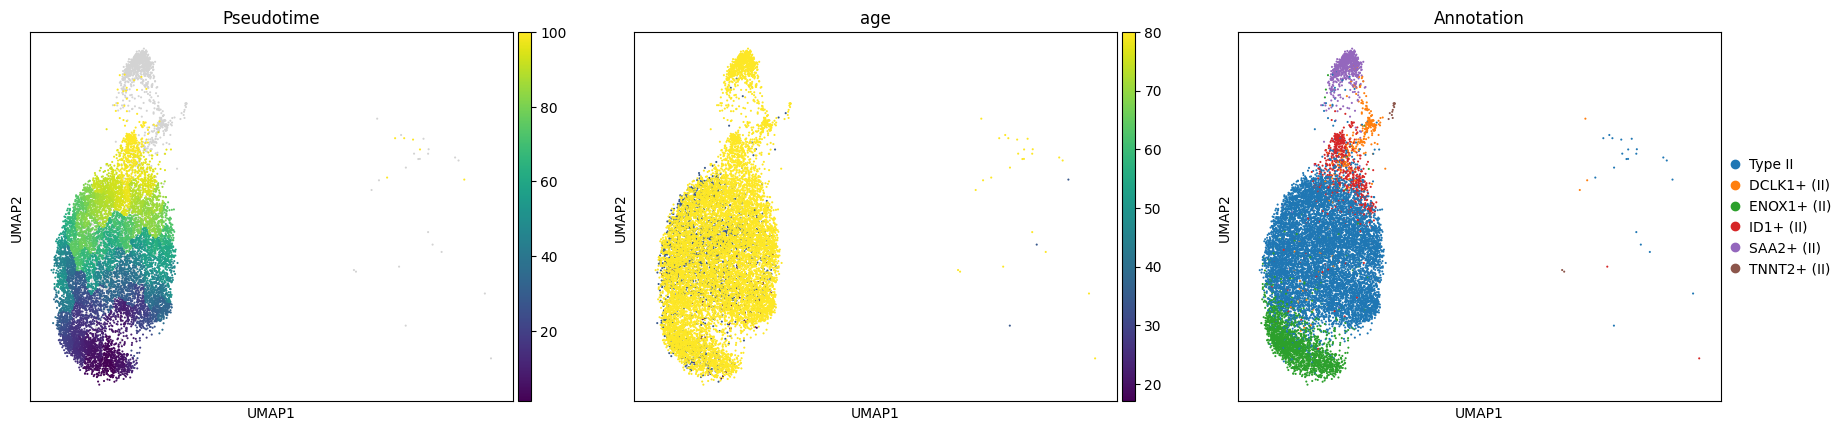

In [15]:
sc.pl.umap(rna_adata, color=['Pseudotime', 'age', 'Annotation'])

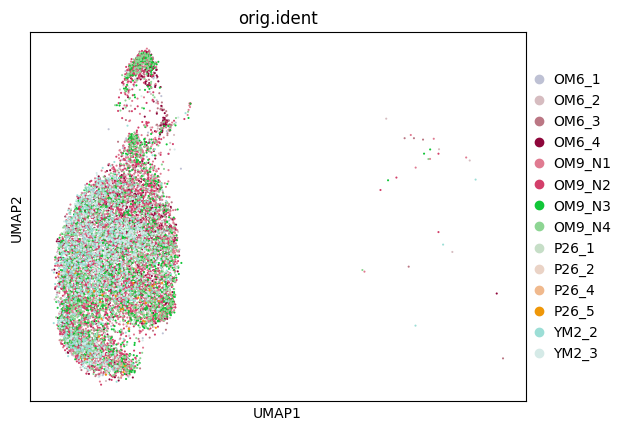

In [16]:
sc.pl.umap(rna_adata, color=['orig.ident'])

In [37]:
#write to file 
rna_adata.write_h5ad(f"{export_dir}/rna_female_type2_YM2_1_removed.h5ad")

# Analysis for ERCC-1 paper

/projects/bgdb/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2051: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


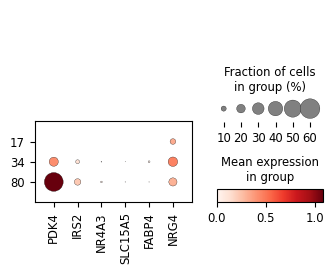

In [10]:
goi_list = ['PDK4', 'IRS2', 'NR4A3', 'SLC15A5', 'FABP4', 'NRG4']
# make age categorical
rna_adata.obs['age_categorical'] = rna_adata.obs['age'].astype('category')
# plot dotplot of goi_list
sc.pl.dotplot(rna_adata, goi_list, groupby='age_categorical')

In [12]:
rna_adata

AnnData object with n_obs × n_vars = 8111 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count', 'age_categorical'
    var: 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'counts_float', 'lognorm'
    obsp: 'connectivities', 'distances'

In [16]:
import scanpy as sc
import pandas as pd
from IPython.display import display

# --------------------------------------------------------------------------
# 1. Pull gene + obs columns into a tidy DataFrame
# --------------------------------------------------------------------------
gene = 'PDK4'

df_cells = sc.get.obs_df(
    rna_adata,
    keys=[gene, 'sample', 'age'],
    layer='lognorm',    # set False (and pass layer='log1p' or similar) if .raw isn't what you want
)

# --------------------------------------------------------------------------
# 2. Pseudobulk: mean expression per sample (sample is the biological replicate)
# --------------------------------------------------------------------------
df_pb = (
    df_cells
    .groupby(['sample', 'age'], as_index=False)[gene]
    .mean()
)

# Quick sanity check on n_samples per age — you need >=2 per age for stats
print(df_pb.groupby('age').size().rename('n_samples'))
print(df_pb)

# Cast age to string for categorical x-axis
df_pb['age'] = df_pb['age'].astype(str)

age
17    1
34    1
80    2
Name: n_samples, dtype: int64
  sample  age      PDK4
0    OM6   80  1.736365
1    OM9   80  0.747903
2    P26   17  0.000000
3    YM2   34  0.423831


2026-04-29 14:58:56 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-29 14:58:56 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-29 14:58:56 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


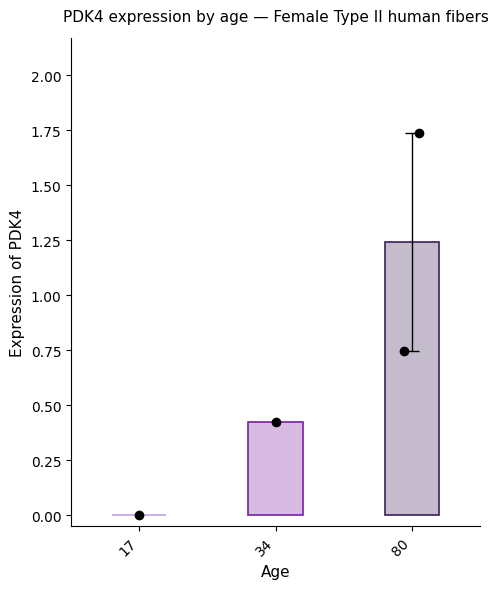

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from IPython.display import display

gene = 'PDK4'
present_ages = sorted(df_pb['age'].unique(), key=lambda a: float(a))

palette = {
    '17': '#C4A0E7',
    '34': '#7B1FA2',
    '80': '#3D1F5C',
}
palette = {a: palette.get(a, '#999999') for a in present_ages}

fig, ax = plt.subplots(figsize=(5, 6))   # match violin-box aspect

# group means + SEM
bar_means = df_pb.groupby('age')[gene].mean().reindex(present_ages)
bar_sems  = df_pb.groupby('age')[gene].sem().reindex(present_ages)

x_pos = np.arange(len(present_ages))

# Translucent face + full-alpha edge — same idiom as plot_violin_box_combo
face_colors = [mcolors.to_rgba(palette[a], alpha=0.3) for a in present_ages]
edge_colors = [palette[a] for a in present_ages]

ax.bar(
    x_pos, bar_means.values,
    yerr=bar_sems.values,
    color=face_colors,
    edgecolor=edge_colors,
    linewidth=1.2,
    width=0.4,
    capsize=5,
    error_kw=dict(elinewidth=1.0, ecolor='black'),
)

# Black sample dots
sns.stripplot(
    data=df_pb, x='age', y=gene, order=present_ages,
    color='black', size=7, jitter=0.06,
    ax=ax,
)

# Axes
ax.set_xticks(x_pos)
ax.set_xticklabels(present_ages, rotation=45, ha='right')
ax.set_ylabel(f'Expression of {gene}', fontsize=11)
ax.set_xlabel('Age', fontsize=11)
ax.set_title(f'{gene} expression by age — Female Type II human fibers',
             fontsize=11, pad=12)
ax.set_ylim(-0.05, max(df_pb[gene].max() * 1.25, 0.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='y', width=0.8)
ax.tick_params(axis='x', width=0.8)
plt.setp(ax.get_yticklabels(), weight='normal')

fig.tight_layout()
plt.close(fig)        # <-- kills the second render
display(fig)

## Molecular age (pseudotime based) to sub-sample

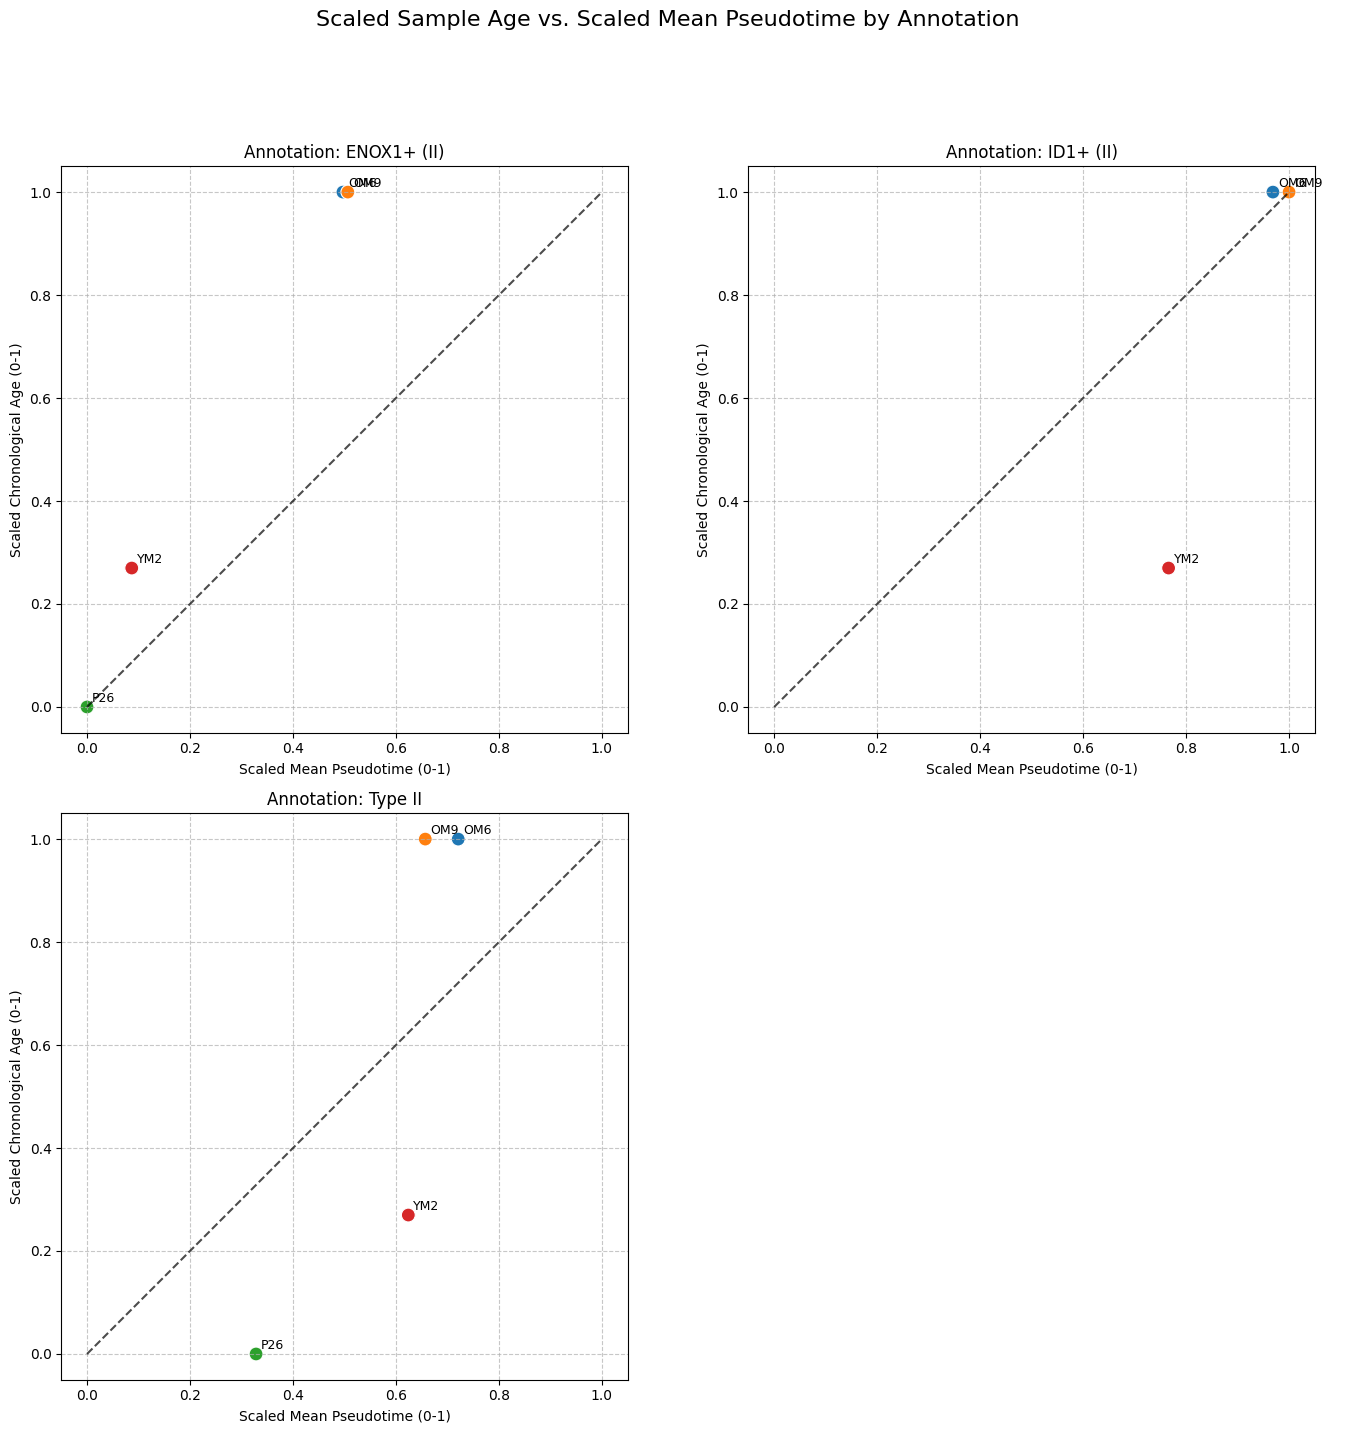

In [18]:
fig_by_annotation, summary_df_all = plot_age_vs_pseudotime_by_annotation(
    rna_adata,
    annotation_col='Annotation', # Make sure this column name is correct
    point_size=100,
    n_subplot_cols=2 # Or 1 if you only have 'Type I' and 'Type II' and want them stacked
)

# AUCell activity scoring of specific pathways

In [19]:
# load geneset of interest
geneset_dir = '/work/hdd/bgdb/asachan/datasets_proj/gene_sets'
# geneset_gmt = ["/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/GOBP_FATTY_ACID_BETA_OXIDATION.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_CITRATE_CYCLE_TCA_CYCLE.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_GLYCOLYSIS_GLUCONEOGENESIS.v2024.1.Hs.gmt",
#                "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_OXIDATIVE_PHOSPHORYLATION.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM.v2024.1.Hs.gmt"]
# geneset_df = gmt_to_decoupler_multiple_pathways(geneset_gmt)
geneset_gmt = [os.path.join(geneset_dir, 'human/DNA_repair/GOBP_DNA_REPAIR.v2024.1.Hs.gmt'), os.path.join(geneset_dir, 'human/DNA_damage_response/GOBP_DNA_DAMAGE_RESPONSE.v2024.1.Hs.gmt'), 
               os.path.join(geneset_dir, 'human/DNA_repair/REACTOME_DNA_REPAIR.v2024.1.Hs.gmt'), os.path.join(geneset_dir, 'human/DNA_repair/HALLMARK_DNA_REPAIR.v2024.1.Hs.gmt')]
geneset_df = gmt_to_decoupler_multiple_pathways(geneset_gmt, geneset_name='source', genesymbol_name='target')
# get the number of rows in each unique geneset
geneset_size = geneset_df['source'].value_counts()
display(geneset_size)
display(geneset_df)
# custom_atrophy_pathway = ["UBB","UBC","FBXO32","TRIM63","MDM2","FBXO30","CAMK2B","TIE1","PSMA1","PSMA2","PSMA3","PSMA4","PSMA5","PSMA6","PSMA7","PSMB1","PSMB2","PSMB3","PSMB4","FBXO21","FBXO31","NEDD4","UBE2B","UBE2G1","UBE2J1","CTSL","CTSV","BNIP3","DEPP1","GABARAPL1","MAP1LC3","RETREG1","SQSTM1","CAPN1","CAPN2","ATF4","FOXO1","FOXO3A","HDAC9","RUNX1","AMPD3","CHRNA1","CDKN1A"]
# geneset_df = pd.DataFrame({'geneset': "Atrophy Pathway (PMID: 31325479)", 'genesymbol': custom_atrophy_pathway})
# geneset_df


source
GOBP_DNA_DAMAGE_RESPONSE    906
GOBP_DNA_REPAIR             615
REACTOME_DNA_REPAIR         332
HALLMARK_DNA_REPAIR         150
Name: count, dtype: int64

,source,target
0,GOBP_DNA_REPAIR,ABL1
1,GOBP_DNA_REPAIR,ABRAXAS1
2,GOBP_DNA_REPAIR,ACTB
3,GOBP_DNA_REPAIR,ACTL6A
4,GOBP_DNA_REPAIR,ACTL6B
...,...,...
1998,HALLMARK_DNA_REPAIR,VPS37B
1999,HALLMARK_DNA_REPAIR,VPS37D
2000,HALLMARK_DNA_REPAIR,XPC
2001,HALLMARK_DNA_REPAIR,ZNF707


In [20]:
%%time
decoupler.mt.aucell(
    rna_adata,
    geneset_df,
    raw=False,
    verbose=True
)

2026-04-29 14:59:16 | [INFO] aucell - Running aucell
2026-04-29 14:59:16 | [INFO] Extracted omics mat with 8111 rows (observations) and 48355 columns (features)
2026-04-29 14:59:17 | [WARNING] 10609 features of mat are empty, they will be removed
2026-04-29 14:59:17 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-04-29 14:59:17 | [INFO] Network has 1023 unique features and 4 unique sources
2026-04-29 14:59:17 | [INFO] aucell - calculating 4 AUCs for 37746 targets across 8111 observations, categorizing features at rank=1888


  0%|          | 0/8111 [00:00<?, ?it/s]

2026-04-29 14:59:27 | [INFO] aucell - done


CPU times: user 1min 41s, sys: 5min 27s, total: 7min 8s
Wall time: 10.4 s


In [21]:
dna_damage_pathways = [
    "GOBP_DNA_REPAIR",
    "GOBP_DNA_DAMAGE_RESPONSE",
    "REACTOME_DNA_REPAIR",
    "HALLMARK_DNA_REPAIR"
]
# metabolic_pathways = [
#     "GOBP_FATTY_ACID_BETA_OXIDATION",
#     "KEGG_CITRATE_CYCLE_TCA_CYCLE",
#     "KEGG_GLYCOLYSIS_GLUCONEOGENESIS",
#     "KEGG_OXIDATIVE_PHOSPHORYLATION",
#     "REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM",
#     "REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM"
# ]

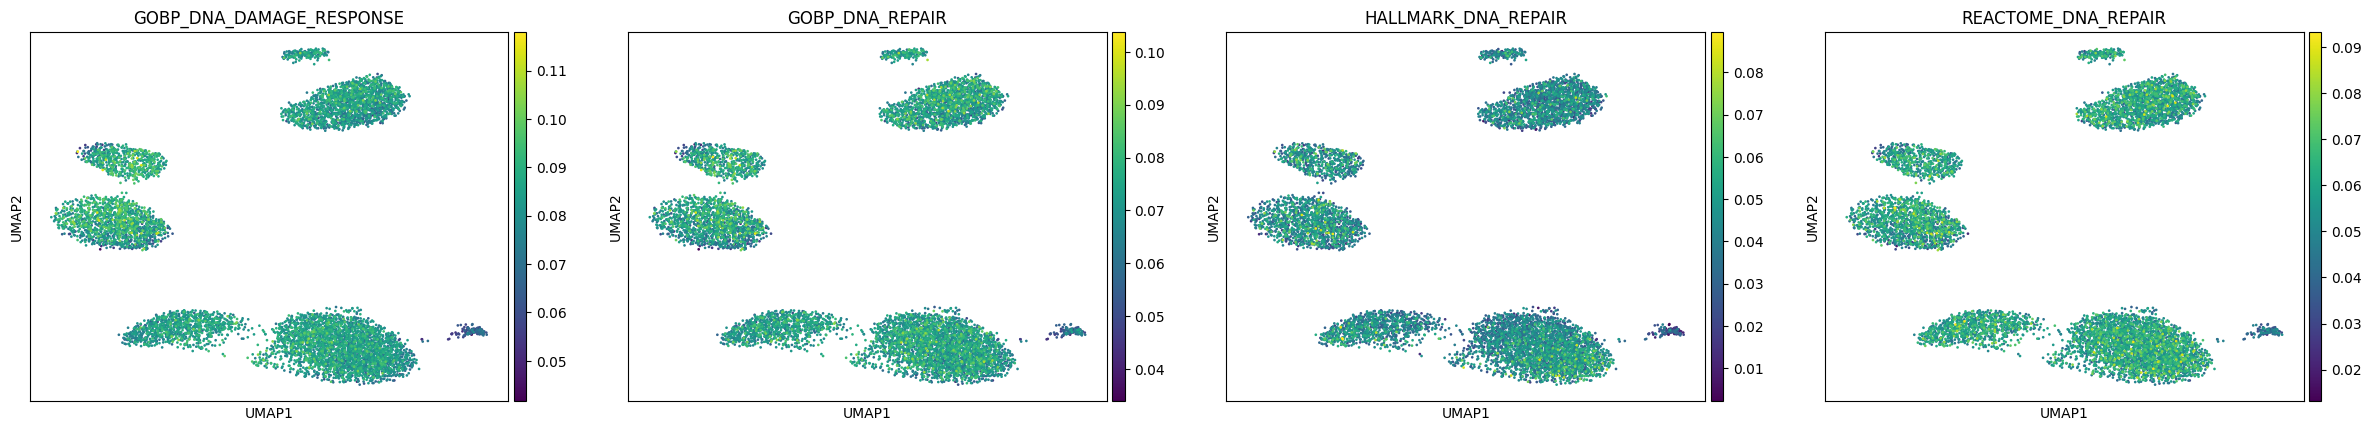

In [22]:
# Copy AUCell scores to obs so you can use them as color
aucell_df = rna_adata.obsm['score_aucell']
for col in aucell_df.columns:
    rna_adata.obs[col] = aucell_df[col].values

# Then plot on UMAP
sc.pl.umap(rna_adata, color=aucell_df.columns.tolist())

### Plot samples ordered by score to select outliers for bar-plot comparitive analysis between cohorts

In [23]:
# get a df of sample ID, sample score per cell type and age
sample_scores = rna_adata.obs[['sample','age', 'Annotation']+dna_damage_pathways].copy()
# average scores per sample and group by Annotation
sample_scores_avg = sample_scores.groupby(['sample', 'Annotation']).mean().reset_index()
sample_scores_avg.head()

,sample,Annotation,age,GOBP_DNA_REPAIR,GOBP_DNA_DAMAGE_RESPONSE,REACTOME_DNA_REPAIR,HALLMARK_DNA_REPAIR
0,OM6,Type II,80.0,0.069081,0.082947,0.053932,0.040572
1,OM6,ENOX1+ (II),80.0,0.070160,0.084773,0.053313,0.037256
2,OM6,ID1+ (II),80.0,0.069252,0.083925,0.053840,0.040785
3,OM9,Type II,80.0,0.069224,0.080751,0.055648,0.039817
4,OM9,ENOX1+ (II),80.0,0.070070,0.082106,0.054242,0.037565


## Plots wrt age

In [24]:
# Use cell-level data directly from adata.obs
cell_level_scores_df = rna_adata.obs[['sample', 'age', 'Annotation', 'Pseudotime'] + dna_damage_pathways].copy()
# geneset_sizes_data = {
#     'KEGG_OXIDATIVE_PHOSPHORYLATION': 132,
#     'GOBP_FATTY_ACID_BETA_OXIDATION': 75,
#     'KEGG_GLYCOLYSIS_GLUCONEOGENESIS': 62,
#     'KEGG_CITRATE_CYCLE_TCA_CYCLE': 31,
#     'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM': 21,
#     'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM': 14
# }
geneset_sizes_data = {
    'GOBP_DNA_REPAIR': 615,
    'GOBP_DNA_DAMAGE_RESPONSE': 906,
    'REACTOME_DNA_REPAIR': 332,
    'HALLMARK_DNA_REPAIR': 150
}
geneset_sizes_series = pd.Series(geneset_sizes_data)

2026-04-29 15:00:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/projects/bgdb/asachan/bioinfo_analysis/human_SKM_multimodal_analysis/py_scripts/utils.py:1190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  violin = sns.violinplot(
2026-04-29 15:00:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-29 15:00:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-04-29 15:00:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-29 15:00:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


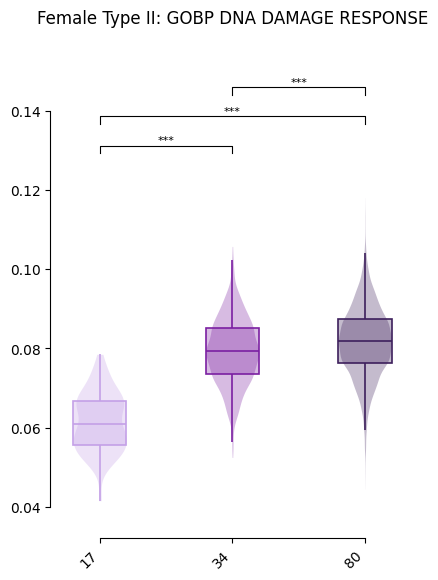

<Figure size 640x480 with 0 Axes>

In [27]:
plot_data = cell_level_scores_df.copy()
plot_data['age'] = plot_data['age'].astype(str)

custom_colors = {
    '17': '#C4A0E7',
    '34': '#7B1FA2',
    '80': '#3D1F5C'
}

# custom_colors = {
#     '38': '#87CEEB',  # Sky blue
#     '45': '#4682B4',  # Steel blue
#     '82': '#191970'  # Midnight blue,
# }

fig = plot_violin_box_combo(
    data=plot_data,
    x_var='age',
    y_var='GOBP_DNA_DAMAGE_RESPONSE',
    title='Female Type II: GOBP DNA DAMAGE RESPONSE',
    x_ticks=['17','34','80'],
    palette=custom_colors,
    rotation=45,
    show_scatter=False
)

# Display the plot
from IPython.display import display
display(fig)
# save as pdf 
#fig.savefig('/ocean/projects/cis240075p/asachan/datasets/senescence_datasets/mouse_liver/figures/cellage_scores.pdf', bbox_inches='tight')

In [ ]:
def downsample_wrt_obs_value(
    adata: AnnData,
    age_to_downsample,
    n_keep: int,
    obs_col: str = 'Pseudotime_typeII',
    age_col: str = 'age',
) -> AnnData:
    """
    Within `age_to_downsample`, keep only the n_keep cells with highest pseudotime.
    All other age groups pass through unchanged. NaN pseudotimes in the target
    group are dropped (nlargest skips them); NaNs elsewhere are preserved.
    """
    obs = adata.obs
    target_mask = (obs[age_col] == age_to_downsample).values
    n_target = target_mask.sum()

    if n_target <= n_keep:
        print(f"Age {age_to_downsample}: {n_target} ≤ n_keep ({n_keep}); returning unchanged.")
        return adata.copy()

    # Top n_keep cells *within* the target group, ranked by pseudotime
    top_idx = obs.loc[target_mask, obs_col].nlargest(n_keep).index

    # Mask: keep if (not in target group) OR (in target group AND in top-n)
    keep_mask = ~target_mask | obs.index.isin(top_idx)
    out = adata[keep_mask].copy()

    threshold = obs.loc[top_idx, obs_col].min()
    print(f"Age {age_to_downsample}: kept {n_keep}/{n_target} cells "
          f"(obs_value ≥ {threshold:.3f}, ~{n_keep/n_target*100:.0f}th-percentile cut from below)")
    return out

In [41]:
rna_adata_ds = downsample_wrt_obs_value(
    rna_adata,
    age_to_downsample=80,
    n_keep=2000,
    obs_col='HALLMARK_DNA_REPAIR',
)

Age 80: kept 2000/6000 cells (pseudotime ≥ 0.045, ~33th-percentile cut from below)


2026-04-29 15:56:14 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/projects/bgdb/asachan/bioinfo_analysis/human_SKM_multimodal_analysis/py_scripts/utils.py:1190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  violin = sns.violinplot(
2026-04-29 15:56:15 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-29 15:56:15 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-29 15:56:15 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-29 15:56:15 | [INFO] Using ca

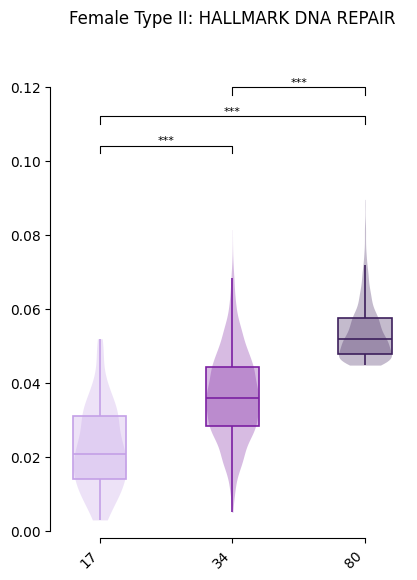

<Figure size 640x480 with 0 Axes>

In [46]:
cell_level_scores_df = rna_adata_ds.obs[['sample', 'age', 'Pseudotime', 'Annotation'] + dna_damage_pathways].copy()
plot_data = cell_level_scores_df.copy()
plot_data['age'] = plot_data['age'].astype(str)

custom_colors = {
    '17': '#C4A0E7',
    '34': '#7B1FA2',
    '80': '#3D1F5C'
}

# custom_colors = {
#     '38': '#87CEEB',  # Sky blue
#     '45': '#4682B4',  # Steel blue
#     '82': '#191970'  # Midnight blue,
# }

fig = plot_violin_box_combo(
    data=plot_data,
    x_var='age',
    y_var='HALLMARK_DNA_REPAIR',
    title='Female Type II: HALLMARK DNA REPAIR',
    x_ticks=['17','34','80'],
    palette=custom_colors,
    rotation=45,
    show_scatter=False
)

# Display the plot
from IPython.display import display
display(fig)
# save as pdf 
#fig.savefig('/ocean/projects/cis240075p/asachan/datasets/senescence_datasets/mouse_liver/figures/cellage_scores.pdf', bbox_inches='tight')

## Plots wrt pseudotime

2026-04-29 15:55:46 | [INFO] Animation.save using <class 'matplotlib.animation.PillowWriter'>


⚠ FFmpeg not found - will use GIF format instead

Starting animation creation...
Figure created with 1 animated lines
Creating animation with 200 frames at 30 fps...
Saving as GIF to pathway_animation.gif...
✓ GIF saved successfully!


/projects/bgdb/asachan/bioinfo_analysis/human_SKM_multimodal_analysis/py_scripts/pathway_animation.gif


Animation saved! Click the link above to download.

Animation creation complete!


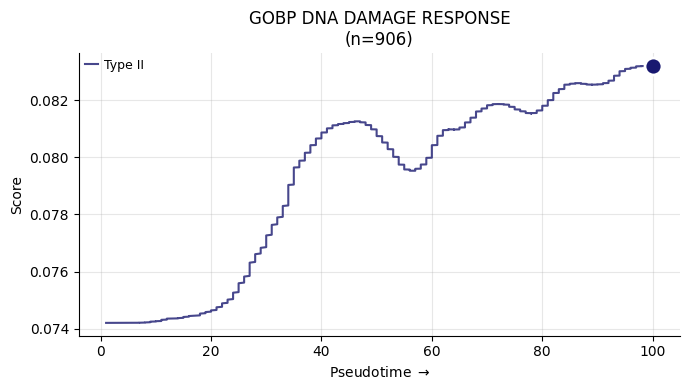

In [45]:
# ====== USAGE ======
plot_colors = {'Type II': '#191970'}
legend_labels = {'Type II': 'Type II'}

# First, let's check if ffmpeg is available
import subprocess
try:
    result = subprocess.run(['ffmpeg', '-version'], 
                          capture_output=True, text=True, timeout=5)
    print("✓ FFmpeg is installed")
    use_gif_format = False
except:
    print("⚠ FFmpeg not found - will use GIF format instead")
    use_gif_format = True

print()


# Your list of score columns
score_cols_to_plot = ['GOBP_DNA_DAMAGE_RESPONSE']

# Create animation
anim_result = create_animated_pathway_plot(
    df_cell_level=cell_level_scores_df,
    score_cols=score_cols_to_plot,
    pseudotime_key='Pseudotime',
    group_by_key='Annotation',
    smoothing_method='gaussian',
    smoothing_strength=120.0,  # Smoother lines
    geneset_sizes=geneset_sizes_series,
    groups_to_plot=['Type II'],
    colors_dict=plot_colors,
    legend_labels_map=legend_labels,
    n_subplot_cols=1,
    figsize_per_subplot=(7, 4),
    nframes=200,  # More frames = smoother
    fps=30,
    dot_size=150,
    output_file='pathway_animation.mp4',
    use_gif=use_gif_format  # Will auto-detect
)

print("\n" + "=" * 60)
print("Animation creation complete!")
print("=" * 60)

In [47]:
# write to file 
rna_adata_ds.write_h5ad(f"{export_dir}/rna_objects/rna_female_type2_ds_wrt_HALLMARK_DNA_REPAIR.h5ad")